In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error
from math import sqrt

In [ ]:
df = pd.read_csv("uber.csv")

In [ ]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [ ]:
df.dropna(inplace=True)

In [ ]:
df = df.drop(['Unnamed: 0','key'],axis=1)

In [ ]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['year']=df['pickup_datetime'].dt.year
df['month']=df['pickup_datetime'].dt.month
df['day']=df['pickup_datetime'].dt.day
df['hour']=df['pickup_datetime'].dt.hour

df=df.drop('pickup_datetime',axis=1)
df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17


In [ ]:
df= df[(df['fare_amount']>0) & (df['fare_amount']<200)]

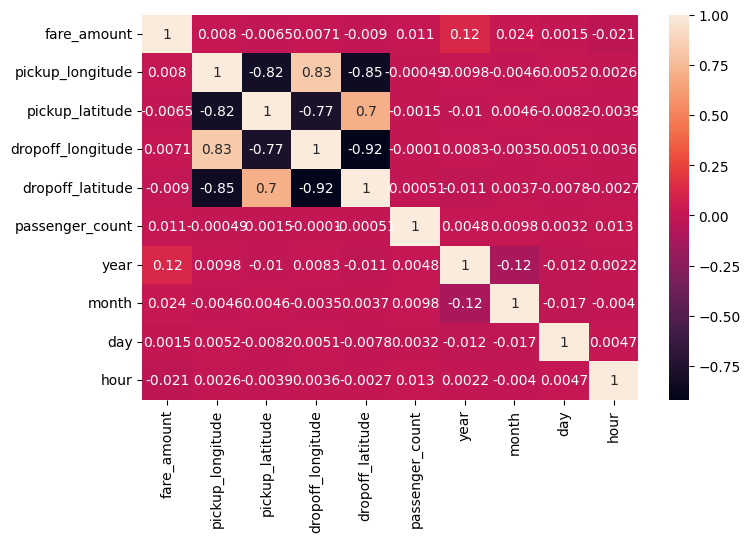

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [ ]:
print(df.corr())

                   fare_amount  pickup_longitude  ...       day      hour
fare_amount           1.000000          0.007987  ...  0.001467 -0.021142
pickup_longitude      0.007987          1.000000  ...  0.005165  0.002563
pickup_latitude      -0.006466         -0.816352  ... -0.008248 -0.003929
dropoff_longitude     0.007055          0.833049  ...  0.005053  0.003614
dropoff_latitude     -0.008983         -0.846365  ... -0.007835 -0.002689
passenger_count       0.010808         -0.000488  ...  0.003228  0.013190
year                  0.120005          0.009843  ... -0.012113  0.002155
month                 0.023716         -0.004639  ... -0.017386 -0.003958
day                   0.001467          0.005165  ...  1.000000  0.004654
hour                 -0.021142          0.002563  ...  0.004654  1.000000

[10 rows x 10 columns]


In [ ]:
X=df.drop("fare_amount",axis=1)
y=df['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression R2: ",r2_score(y_test,y_pred_lr))
print("Linear Regression RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred_lr)))

Linear Regression R2:  0.01732680293696376
Linear Regression RMSE:  9.744957274890893


In [24]:
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
print("Random forest R2: ",r2_score(y_test,y_pred_rf))
print("Random forest RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred_rf)))

Random forest R2:  0.8117441808772815
Random forest RMSE:  4.265300059834447
